In [ ]:
#https://www.kaggle.com/datasets/roopacalistus/superstore?resource=download

import pandas as pd

# Load your dataset
df = pd.read_csv("SampleSuperstore.csv")  # replace with your file path

# Group by Ship Mode and calculate total sales, total profit, and average sales
ship_summary = df.groupby('Ship Mode').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum'
}).reset_index()

# Flatten the column names
ship_summary.columns = ['Ship Mode', 'Total Sales', 'Average Sales', 'Total Profit', 'Average Profit', 'Total Quantity']

# Sort by Total Sales to see which Ship Mode drives the most revenue
ship_summary_sorted = ship_summary.sort_values(by='Total Sales', ascending=False)

print("Shipping mode impact on revenue:")
print(ship_summary_sorted)

# Optional: Highlight positive vs negative profit impact
print("\nShipping modes with negative total profit (costly methods):")
negative_profit = ship_summary_sorted[ship_summary_sorted['Total Profit'] < 0]
print(negative_profit)

Shipping mode impact on revenue:
        Ship Mode   Total Sales  Average Sales  Total Profit  Average Profit  \
3  Standard Class  1.358216e+06     227.583067   164088.7875       27.494770   
2    Second Class  4.591936e+05     236.089239    57446.6354       29.535545   
0     First Class  3.514284e+05     228.497024    48969.8399       31.839948   
1        Same Day  1.283631e+05     236.396179    15891.7589       29.266591   

   Total Quantity  
3           22797  
2            7423  
0            5693  
1            1960  

Shipping modes with negative total profit (costly methods):
Empty DataFrame
Columns: [Ship Mode, Total Sales, Average Sales, Total Profit, Average Profit, Total Quantity]
Index: []


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("SampleSuperstore.csv")  # replace with your file path

# Group by Ship Mode, Region, Segment, and Category
grouped = df.groupby(['Ship Mode', 'Region', 'Segment', 'Category']).agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum'
}).reset_index()

# Flatten multi-level column names
grouped.columns = [
    'Ship Mode', 'Region', 'Segment', 'Category',
    'Total Sales', 'Average Sales', 'Total Profit', 'Average Profit', 'Total Quantity'
]

# Sort by Total Sales to see which combinations drive the most revenue
top_combinations = grouped.sort_values(by='Total Sales', ascending=False)
print("Top revenue-driving combinations:")
print(top_combinations.head(10))  # top 10 combinations

# Sort by Total Profit to see which combinations are most profitable
profitable_combinations = grouped.sort_values(by='Total Profit', ascending=False)
print("\nMost profitable combinations:")
print(profitable_combinations.head(10))

# Optional: identify combinations with negative total profit
negative_profit_combinations = grouped[grouped['Total Profit'] < 0]
print("\nCombinations with negative profit (costly methods):")
print(negative_profit_combinations)

Top revenue-driving combinations:
          Ship Mode   Region    Segment         Category  Total Sales  \
118  Standard Class     East   Consumer       Technology   86870.5310   
136  Standard Class     West   Consumer       Technology   72915.5390   
134  Standard Class     West   Consumer        Furniture   70492.3555   
116  Standard Class     East   Consumer        Furniture   68724.4210   
135  Standard Class     West   Consumer  Office Supplies   68352.6060   
108  Standard Class  Central   Consumer  Office Supplies   67949.3850   
117  Standard Class     East   Consumer  Office Supplies   53988.5140   
107  Standard Class  Central   Consumer        Furniture   53779.7814   
137  Standard Class     West  Corporate        Furniture   50382.1980   
109  Standard Class  Central   Consumer       Technology   50141.8040   

     Average Sales  Total Profit  Average Profit  Total Quantity  
118     575.301530    13771.8290       91.204166             550  
136     396.280103    11690.

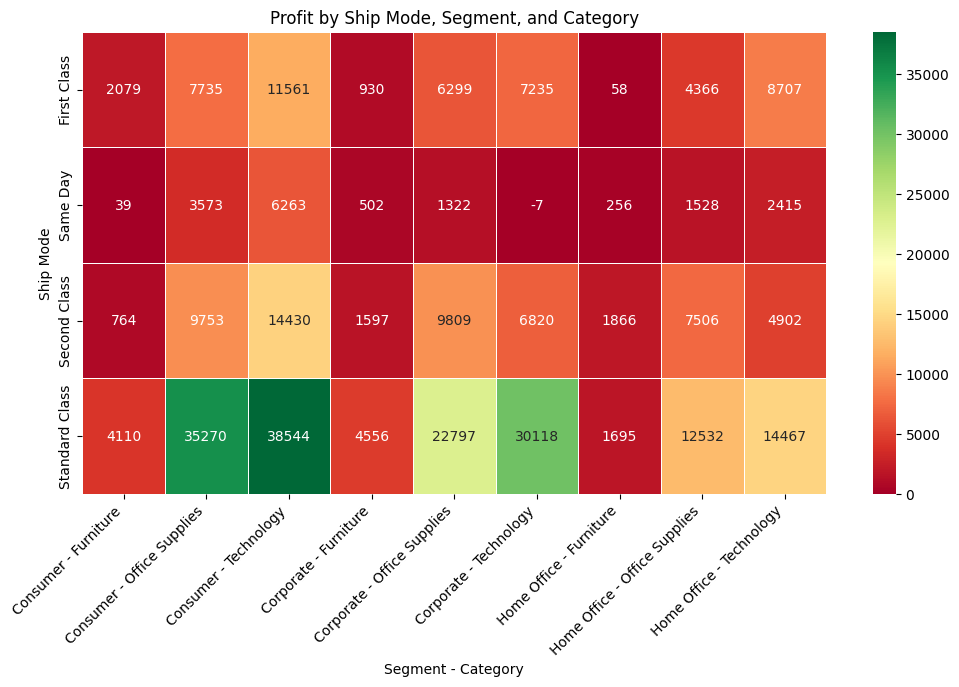

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("SampleSuperstore.csv")  # replace with your file path

# Group by Ship Mode, Segment, and Category
grouped = df.groupby(['Ship Mode', 'Segment', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Pivot the table to create a matrix for heatmap
# Rows = Ship Mode, Columns = Category + Segment combined
grouped['Segment_Category'] = grouped['Segment'] + ' - ' + grouped['Category']
pivot_table = grouped.pivot(index='Ship Mode', columns='Segment_Category', values='Profit')

# Plot the heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=0.5)
plt.title("Profit by Ship Mode, Segment, and Category")
plt.ylabel("Ship Mode")
plt.xlabel("Segment - Category")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:

#https://www.kaggle.com/datasets/yashyennewar/product-sales-dataset-2023-2024

import sqlite3
import pandas as pd

# create database in memory
conn = sqlite3.connect(":memory:")

cursor = conn.cursor()

df = pd.read_csv("product_sales_dataset_final.csv")
# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Check again
#print(df.columns)
df.head()
df.to_sql("sales", conn, if_exists="replace", index=False)
def run_query(query, title):
    print("\n" + "="*50)
    print(title)
    print("="*50)

    result = pd.read_sql_query(query, conn)
    print(result)


#Revenue + Profit + Margin per Product
query = """
SELECT
    Product_Name,
    SUM(Quantity) AS total_units,
    SUM(Revenue) AS total_revenue,
    SUM(Profit) AS total_profit,
    SUM(Profit) * 1.0 / SUM(Revenue) AS profit_margin
FROM sales
GROUP BY Product_Name
ORDER BY total_revenue DESC
"""

run_query(query, "Revenue / Profit / Margin per Product")



#Top 10 Performing Products
query = """
SELECT
    Product_Name,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY Product_Name
ORDER BY total_revenue DESC
LIMIT 10
"""

run_query(query, "Top 10 Products")




#Underperforming Products
query = """
SELECT
    Product_Name,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY Product_Name
ORDER BY total_revenue ASC
LIMIT 10
"""

run_query(query, "Worst Products")


#Most Profitable Products
query = """
SELECT
    Product_Name,
    SUM(Profit) AS total_profit
FROM sales
GROUP BY Product_Name
ORDER BY total_profit DESC
LIMIT 10
"""

run_query(query, "Most Profitable Products")



#Lowest Profit Margin


query = """
SELECT
    Product_Name,
    SUM(Profit) * 1.0 / SUM(Revenue) AS profit_margin
FROM sales
GROUP BY Product_Name
HAVING SUM(Revenue) > 0
ORDER BY profit_margin ASC
LIMIT 10
"""

run_query(query, "Lowest Margin Products")

#Category Performance
query = """
SELECT
    Category,
    SUM(Revenue) AS total_revenue,
    SUM(Profit) AS total_profit,
    SUM(Profit) * 1.0 / SUM(Revenue) AS profit_margin
FROM sales
GROUP BY Category
ORDER BY total_revenue DESC
"""

run_query(query, "Category Performance")




#Region Performance
query = """
SELECT
    Region,
    SUM(Revenue) AS total_revenue,
    SUM(Profit) AS total_profit
FROM sales
GROUP BY Region
ORDER BY total_revenue DESC
"""

run_query(query, "Region Performance")


#Monthly Revenue
query = """
SELECT
    strftime('%Y-%m', Order_Date) AS month,
    SUM(Revenue) AS total_revenue,
    SUM(Profit) AS total_profit
FROM sales
GROUP BY month
ORDER BY month
"""

run_query(query, "Monthly Revenue")

#Top Customers
query = """
SELECT
    Customer_Name,
    SUM(Revenue) AS total_revenue,
    SUM(Profit) AS total_profit
FROM sales
GROUP BY Customer_Name
ORDER BY total_revenue DESC
LIMIT 10
"""

run_query(query, "Top Customers")


#Best Selling Products by Quantity
query = """
SELECT
    Product_Name,
    SUM(Quantity) AS total_units
FROM sales
GROUP BY Product_Name
ORDER BY total_units DESC
LIMIT 10
"""

run_query(query, "Best Selling Products")


Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Revenue', 'Profit'],
      dtype='object')

Revenue / Profit / Margin per Product
             Product_Name  total_units  total_revenue  total_profit  \
0   Tempur-Pedic Mattress        10333     9061755.86    2134208.80   
1             Instant Pot        18200     8903475.26    1689924.16   
2             MacBook Air         8763     7362516.81    1028767.59   
3             Apple Watch        12368     6834472.35     957992.87   
4         Apple iPhone 14         7642     5740819.18     808671.16   
5                iPad Pro        10075     5574458.89     781602.78   
6        KitchenAid Mixer         9831     4989740.69     944239.08   
7            Storage Rack         9394     4463941.27    1052179.55   
8       Brooklinen Sheets         8242     3981027.44     933904.24   
9      Samsung Galaxy S23         6

In [ ]:
#https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('employee_attriction.csv')  # Replace with your file path

# Encode binary categorical variables
binary_cols = ['Attrition', 'Over18', 'OverTime', 'Gender', 'MaritalStatus']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encode multi-class categorical variables
multi_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Features and target
X = df.drop(['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours'], axis=1)
y = df['Attrition']

In [ ]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numeric features for some models (optional for Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#rf = RandomForestClassifier(n_estimators=100, random_state=42)
#rf.fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
# Predict
y_pred = rf.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8684807256235828
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       380
           1       0.71      0.08      0.15        61

    accuracy                           0.87       441
   macro avg       0.79      0.54      0.54       441
weighted avg       0.85      0.87      0.82       441



               Feature  Importance
11       MonthlyIncome    0.074085
0                  Age    0.061309
15            OverTime    0.057508
20   TotalWorkingYears    0.053391
1            DailyRate    0.049506
23      YearsAtCompany    0.046049
12         MonthlyRate    0.045474
19    StockOptionLevel    0.044749
6           HourlyRate    0.043269
24  YearsInCurrentRole    0.040422


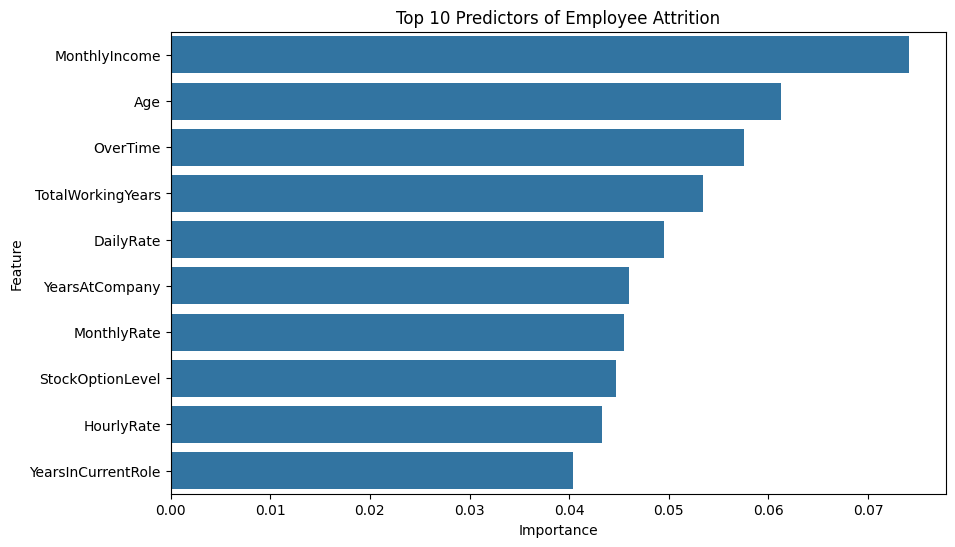

In [ ]:
# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Show top 10 predictors
print(feature_importances.head(10))

# Optional: Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title("Top 10 Predictors of Employee Attrition")
plt.show()

Classification Report (Attrition = Yes focus):

              precision    recall  f1-score   support

No Attrition       0.92      0.80      0.86       370
   Attrition       0.38      0.63      0.48        71

    accuracy                           0.78       441
   macro avg       0.65      0.72      0.67       441
weighted avg       0.83      0.78      0.80       441


Top 10 Features Driving Attrition:
                 Feature  Importance
15              OverTime    0.077909
19      StockOptionLevel    0.062088
23        YearsAtCompany    0.054080
11         MonthlyIncome    0.051753
8               JobLevel    0.051032
26  YearsWithCurrManager    0.050298
20     TotalWorkingYears    0.048148
10         MaritalStatus    0.041183
0                    Age    0.039756
22       WorkLifeBalance    0.038450


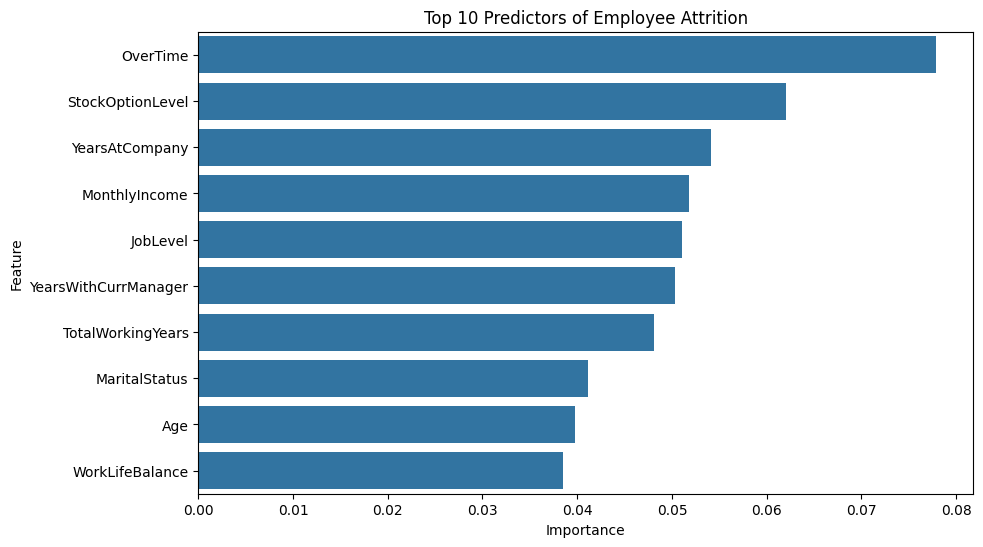

In [ ]:
#pip install imbalanced-learn scikit-learn pandas matplotlib seaborn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('employee_attriction.csv')

# Encode binary categorical variables
binary_cols = ['Attrition', 'Over18', 'OverTime', 'Gender', 'MaritalStatus']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encode multi-class categorical variables
multi_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Drop irrelevant or constant columns
X = df.drop(['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours'], axis=1)
y = df['Attrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from imblearn.combine import SMOTEENN

sm = SMOTEENN(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# Train Random Forest with class_weight to further help imbalance
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)


# Predict
y_pred = rf.predict(X_test_scaled)

# Evaluation
print("Classification Report (Attrition = Yes focus):\n")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

# Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Features Driving Attrition:")
print(feature_importances.head(10))

# Plot top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title("Top 10 Predictors of Employee Attrition")
plt.show()